# 07 — Stage 3 Training (Signal Classifier)

**BBL514E Pattern Recognition — Term Project (MVP)**

## hedef
Final hierarchical signal classifier (Buy/Sell/Hold). Input:
$$ x_{stage3} = [\,x_{osc};\ \hat p(z_{trend} \mid x_{trend});\ \hat p(z_{regime} \mid x_{macro})\,] $$

- $x_{osc}$ — Stage 3 oscillator features (RSI, MACD, Stoch, BB, ATR, OBV, ...)
- $\hat p(z_{trend})$ — Stage 1 OOF posterior (Uptrend/Downtrend/Sideways)
- $\hat p(z_{regime})$ — Stage 2 OOF GMM posterior (3 regime clusters)

Bu, hierarchical Bayesian decision theory'nin pratik gerçekleştirimi — alt seviye posterior'lar üst karara feature olarak eklenir.

## yöntem
- 2 sınıflandırıcı: **LDA** + **MLP** (Stage 1 ile aynı set)
- Walk-forward + Optuna (3 ay step, Stage 1 ile aynı kurulum)
- Stage 1 OOF olarak **LDA** seçildi (daha tutarlı klasik PR pipeline'ı: LDA → GMM → LDA / MLP)
- `class_weight='balanced'` Hold/Buy/Sell dengesizliğini telafi eder

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.decomposition import PCA

plt.style.use("seaborn-v0_8-darkgrid")
pd.set_option("display.max_columns", 50)

from src.utils.config import cfg
from src.utils.helpers import save_csv, chronological_train_test_split
from src.models.stage3_trainer import tune_stage3, train_stage3
from src.models.pipeline import HierarchicalSoftPipeline
from src.evaluation.metrics import compute_all_metrics

config = cfg()
TEST_SIZE = config["training"]["test_size"]
RANDOM_STATE = config["training"]["random_state"]
STEP_MONTHS = 3
MIN_TRAIN_MONTHS = 6
N_TRIALS_LDA = 10
N_TRIALS_MLP = 12

In [2]:
X_osc = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "btc_features_stage3.csv", index_col=0, parse_dates=True)
y_signal = pd.read_csv(PROJECT_ROOT / "data" / "labels" / "btc_signal_labels_fixed.csv", index_col=0, parse_dates=True).iloc[:, 0]

stage1_oof = pd.read_csv(PROJECT_ROOT / "data" / "labels" / "btc_stage1_oof_lda.csv", index_col=0, parse_dates=True)
stage2_oof = pd.read_csv(PROJECT_ROOT / "data" / "labels" / "btc_oof_regime_posterior.csv", index_col=0, parse_dates=True)

X_osc = X_osc.dropna()
common_idx = X_osc.index.intersection(y_signal.index).intersection(stage1_oof.index).intersection(stage2_oof.index)
X_osc = X_osc.loc[common_idx]
y = y_signal.loc[common_idx]
stage1_oof = stage1_oof.loc[common_idx]
stage2_oof = stage2_oof.loc[common_idx]

print(f"Aligned data: X_osc={X_osc.shape}, stage1_oof={stage1_oof.shape}, stage2_oof={stage2_oof.shape}")
print(f"y={y.shape}")
print(f"Date range: {X_osc.index.min().date()} → {X_osc.index.max().date()}")
print(f"Class dist:\n{(y.value_counts(normalize=True) * 100).round(1)}")

Aligned data: X_osc=(3366, 18), stage1_oof=(3366, 3), stage2_oof=(3366, 3)
y=(3366,)
Date range: 2016-09-26 → 2025-12-25
Class dist:
signal_label
Buy     47.1
Sell    36.9
Hold    16.0
Name: proportion, dtype: float64


In [3]:
# Train-test split
X_osc_train, X_osc_test = chronological_train_test_split(X_osc, test_size=TEST_SIZE)
y_train = y.loc[X_osc_train.index]
y_test = y.loc[X_osc_test.index]
stage1_train = stage1_oof.loc[X_osc_train.index]
stage1_test = stage1_oof.loc[X_osc_test.index]
stage2_train = stage2_oof.loc[X_osc_train.index]
stage2_test = stage2_oof.loc[X_osc_test.index]

print(f"Train: {X_osc_train.shape}, Test: {X_osc_test.shape}")
print(f"Train period: {X_osc_train.index.min().date()} → {X_osc_train.index.max().date()}")
print(f"Test period:  {X_osc_test.index.min().date()} → {X_osc_test.index.max().date()}")

Train: (2861, 18), Test: (505, 18)
Train period: 2016-09-26 → 2024-08-02
Test period:  2024-08-03 → 2025-12-25


## 1. Stage 3 LDA — Optuna walk-forward

In [4]:
t0 = time.time()
lda3_result = tune_stage3(
    X_osc_train, y_train, stage1_train, stage2_train,
    classifier_name="lda", n_trials=N_TRIALS_LDA, save_model=False,
    step_months=STEP_MONTHS, min_train_months=MIN_TRAIN_MONTHS,
)
print(f"\nLDA Stage 3: {time.time() - t0:.1f}s")
print(f"Best params: {lda3_result['best_params']}")
print(f"Walk-forward avg f1_macro: {lda3_result['avg_f1_macro']:.4f}")

2026-05-07 19:54:38 | src.models.stage1_trainer | INFO | Walk-forward: 30 folds, min train window = 6 months


2026-05-07 19:54:39 | src.models.optuna_helpers | INFO | Optuna [stage3_lda] complete: best_f1=0.2492, params={'solver': 'svd'}


2026-05-07 19:54:39 | src.models.stage3_trainer | INFO | Stage 3 best params (lda): {'solver': 'svd'}


2026-05-07 19:54:39 | src.models.stage3_trainer | INFO | Stage 3 Training: lda, 2861 samples, 24 features (18 oscillator + 3 trend + 3 regime), classes=['Hold', 'Buy', 'Sell']


2026-05-07 19:54:39 | src.models.stage1_trainer | INFO | Walk-forward: 89 folds, min train window = 6 months


...

2026-05-07 19:54:40 | src.models.stage3_trainer | INFO |   Fold 86: acc=0.5806, f1_macro=0.2553


2026-05-07 19:54:40 | src.models.stage3_trainer | INFO |   Fold 87: acc=0.2667, f1_macro=0.1404


2026-05-07 19:54:40 | src.models.stage3_trainer | INFO |   Fold 88: acc=1.0000, f1_macro=1.0000


2026-05-07 19:54:40 | src.models.stage3_trainer | INFO |   Average: acc=0.4149, f1_macro=0.2651



LDA Stage 3: 2.2s
Best params: {'solver': 'svd'}
Walk-forward avg f1_macro: 0.2651


## 2. Stage 3 MLP — Optuna walk-forward

In [5]:
t0 = time.time()
mlp3_result = tune_stage3(
    X_osc_train, y_train, stage1_train, stage2_train,
    classifier_name="mlp", n_trials=N_TRIALS_MLP, save_model=False,
    step_months=STEP_MONTHS, min_train_months=MIN_TRAIN_MONTHS,
)
print(f"\nMLP Stage 3: {time.time() - t0:.1f}s")
print(f"Best params: {mlp3_result['best_params']}")
print(f"Walk-forward avg f1_macro: {mlp3_result['avg_f1_macro']:.4f}")

2026-05-07 19:54:40 | src.models.stage1_trainer | INFO | Walk-forward: 30 folds, min train window = 6 months


2026-05-07 19:54:42 | src.models.classifiers | INFO | MLP early stopping at epoch 7


2026-05-07 19:54:42 | src.models.classifiers | INFO | MLP early stopping at epoch 7


2026-05-07 19:54:42 | src.models.classifiers | INFO | MLP early stopping at epoch 6


2026-05-07 19:54:42 | src.models.classifiers | INFO | MLP early stopping at epoch 16


...

2026-05-07 19:55:45 | src.models.stage3_trainer | INFO |   Fold 87: acc=0.5000, f1_macro=0.3066


2026-05-07 19:55:45 | src.models.classifiers | INFO | MLP early stopping at epoch 21


2026-05-07 19:55:45 | src.models.stage3_trainer | INFO |   Fold 88: acc=1.0000, f1_macro=1.0000


2026-05-07 19:55:51 | src.models.stage3_trainer | INFO |   Average: acc=0.5479, f1_macro=0.3153



MLP Stage 3: 70.8s
Best params: {'hidden_idx': 0, 'learning_rate': 0.0044635901521768145, 'batch_size': 64}
Walk-forward avg f1_macro: 0.3153


## 3. Test set evaluation

Test combined feature = osc_test + stage1_test_oof (Stage 1 final model'in test'te ürettiği proba) + stage2_test_oof (Stage 2 GMM'in test'te ürettiği posterior).

In [6]:
X_test_combined = pd.concat([X_osc_test, stage1_test, stage2_test], axis=1)
X_train_combined_clean = pd.concat([X_osc_train, stage1_train, stage2_train], axis=1).fillna(
    pd.concat([X_osc_train, stage1_train, stage2_train], axis=1).median()
)
X_test_combined_clean = X_test_combined.fillna(X_train_combined_clean.median())

test_results = {}
for name, result in [("LDA", lda3_result), ("MLP", mlp3_result)]:
    model = result["model"]
    y_pred = model.predict(X_test_combined_clean)
    y_proba = model.predict_proba(X_test_combined_clean)
    metrics = compute_all_metrics(
        y_test.values, y_pred, y_proba=y_proba, classes=list(model.classes_),
    )
    test_results[name] = metrics
    print(f"\n=== Stage 3 {name} test set ===")
    print(f"  accuracy:        {metrics['accuracy']:.4f}")
    print(f"  balanced_acc:    {metrics['balanced_accuracy']:.4f}")
    print(f"  f1_macro:        {metrics['f1_macro']:.4f}")
    print(f"  mcc:             {metrics['mcc']:.4f}")
    print(f"  roc_auc_ovr:     {metrics.get('roc_auc_ovr', 'N/A')}")
    print(metrics["classification_report"])

2026-05-07 19:55:51 | src.evaluation.metrics | INFO | Metrics: acc=0.3505, bal_acc=0.3315, f1_macro=0.1733, mcc=-0.0209


2026-05-07 19:55:51 | src.evaluation.metrics | INFO | Metrics: acc=0.3842, bal_acc=0.3536, f1_macro=0.2545, mcc=0.0624



=== Stage 3 LDA test set ===
  accuracy:        0.3505
  balanced_acc:    0.3315
  f1_macro:        0.1733
  mcc:             -0.0209
  roc_auc_ovr:     0.5694332945952231
              precision    recall  f1-score   support

         Buy       0.00      0.00      0.00       211
        Hold       0.00      0.00      0.00       116
        Sell       0.35      0.99      0.52       178

    accuracy                           0.35       505
   macro avg       0.12      0.33      0.17       505
weighted avg       0.12      0.35      0.18       505


=== Stage 3 MLP test set ===
  accuracy:        0.3842
  balanced_acc:    0.3536
  f1_macro:        0.2545
  mcc:             0.0624
  roc_auc_ovr:     0.5516598206727171
              precision    recall  f1-score   support

         Buy       0.52      0.16      0.24       211
        Hold       0.00      0.00      0.00       116
        Sell       0.37      0.90      0.52       178

    accuracy                           0.38       505
  

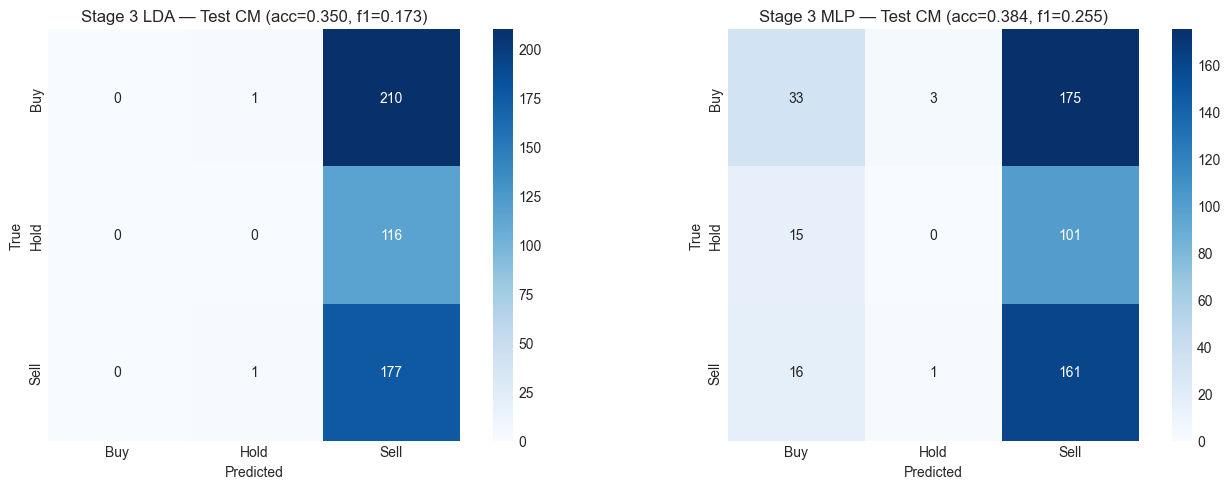

In [7]:
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, name in zip(axes, ["LDA", "MLP"]):
    cm = pd.DataFrame(
        test_results[name]["confusion_matrix"],
        index=lda3_result["model"].classes_,
        columns=lda3_result["model"].classes_,
    )
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, square=True)
    ax.set_title(f"Stage 3 {name} — Test CM (acc={test_results[name]['accuracy']:.3f}, f1={test_results[name]['f1_macro']:.3f})")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "reports" / "stage3_confusion_matrices.png", dpi=120, bbox_inches="tight")
plt.show()

## 4. Decision boundary in PCA 2D (test set)

Hocanın guideline'ında istenmiş — feature uzayını 2D'ye projekte et + her sınıf için karar bölgelerini göster.

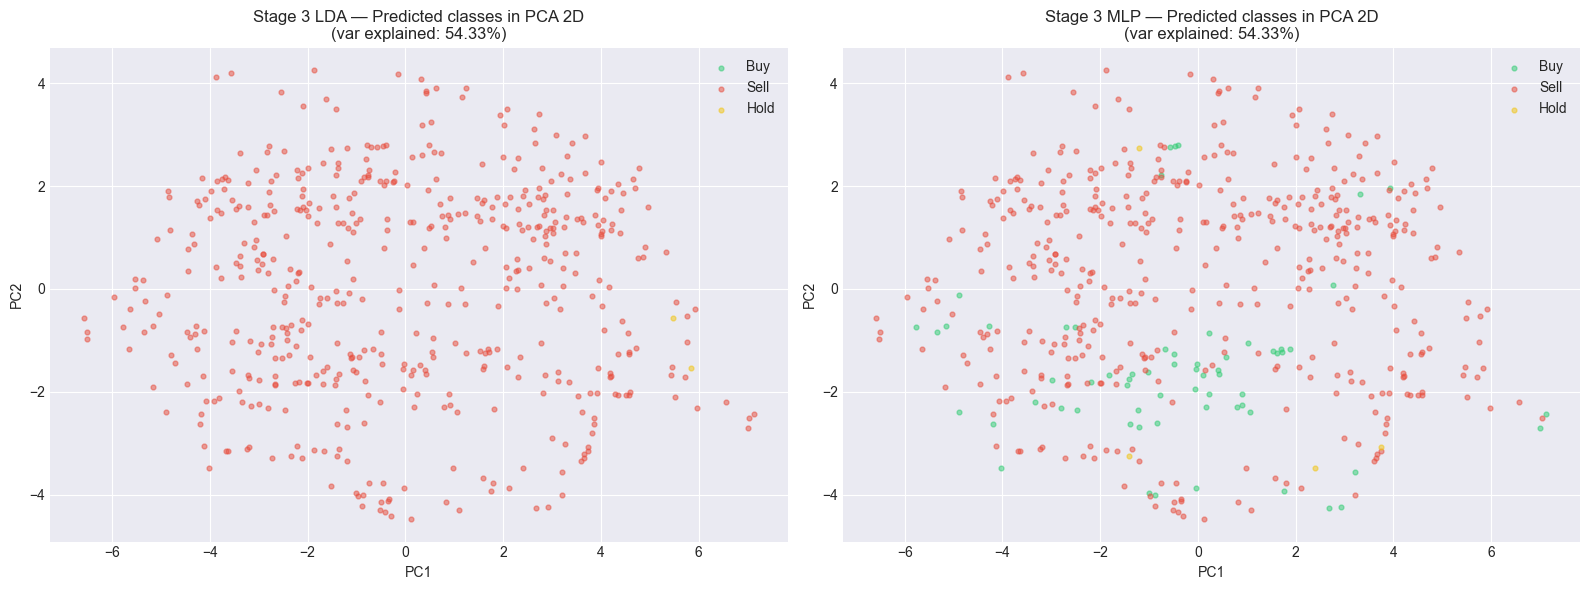

In [8]:
# Use test set in PCA 2D with model decisions overlaid
from sklearn.preprocessing import StandardScaler as _SS
scaler_pca = _SS()
X_test_clean_arr = scaler_pca.fit_transform(X_test_combined_clean.fillna(0))
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_test_pca = pca.fit_transform(X_test_clean_arr)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
color_map = {"Buy": "#2ECC71", "Sell": "#E74C3C", "Hold": "#F1C40F"}

for ax, name in zip(axes, ["LDA", "MLP"]):
    model = lda3_result["model"] if name == "LDA" else mlp3_result["model"]
    y_pred_test = model.predict(X_test_combined_clean)
    for cls, color in color_map.items():
        mask = y_pred_test == cls
        ax.scatter(X_test_pca[mask, 0], X_test_pca[mask, 1], c=color, label=cls, alpha=0.5, s=12)
    ax.set_title(f"Stage 3 {name} — Predicted classes in PCA 2D\n(var explained: {pca.explained_variance_ratio_.sum():.2%})")
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.legend()

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "reports" / "stage3_decision_boundary_pca.png", dpi=120, bbox_inches="tight")
plt.show()

## 5. Save final pipeline + signals

**HierarchicalSoftPipeline** = Stage 1 model + Stage 2 cluster artifact + Stage 3 model.
FastAPI bu artifact'ı yükleyip canlı tahminde kullanacak.

In [9]:
models_dir = PROJECT_ROOT / "app" / "models"
labels_dir = PROJECT_ROOT / "data" / "labels"

# Save Stage 3 models
joblib.dump(lda3_result["model"], models_dir / "stage3_lda.joblib")
joblib.dump(mlp3_result["model"], models_dir / "stage3_mlp.joblib")

# Build full HierarchicalSoftPipeline (LDA path) — load Stage 1 LDA + Stage 2 artifact
stage1_lda = joblib.load(models_dir / "stage1_lda.joblib")
stage2_artifact = joblib.load(models_dir / "stage2_cluster_artifact.joblib")

pipeline_lda = HierarchicalSoftPipeline(stage1_lda, stage2_artifact, lda3_result["model"])
pipeline_mlp = HierarchicalSoftPipeline(stage1_lda, stage2_artifact, mlp3_result["model"])  # uses same Stage 1 LDA OOF

pipeline_lda.save(models_dir / "pipeline_lda")
pipeline_mlp.save(models_dir / "pipeline_mlp")

# Save test predictions for backtest
pred_lda = lda3_result["model"].predict(X_test_combined_clean)
pred_mlp = mlp3_result["model"].predict(X_test_combined_clean)
proba_lda = lda3_result["model"].predict_proba(X_test_combined_clean)
proba_mlp = mlp3_result["model"].predict_proba(X_test_combined_clean)

test_signals = pd.DataFrame({
    "lda_pred": pred_lda,
    "mlp_pred": pred_mlp,
    "y_true": y_test.values,
}, index=y_test.index)
for i, c in enumerate(lda3_result["model"].classes_):
    test_signals[f"lda_proba_{c}"] = proba_lda[:, i]
    test_signals[f"mlp_proba_{c}"] = proba_mlp[:, i]

save_csv(test_signals, labels_dir / "btc_test_signals.csv")

# Summary
summary_df = pd.DataFrame([
    {"model": "Stage3-LDA", "WF_f1": lda3_result["avg_f1_macro"], "WF_acc": lda3_result["avg_accuracy"],
     "test_acc": test_results["LDA"]["accuracy"], "test_f1": test_results["LDA"]["f1_macro"],
     "test_balanced_acc": test_results["LDA"]["balanced_accuracy"], "test_mcc": test_results["LDA"]["mcc"]},
    {"model": "Stage3-MLP", "WF_f1": mlp3_result["avg_f1_macro"], "WF_acc": mlp3_result["avg_accuracy"],
     "test_acc": test_results["MLP"]["accuracy"], "test_f1": test_results["MLP"]["f1_macro"],
     "test_balanced_acc": test_results["MLP"]["balanced_accuracy"], "test_mcc": test_results["MLP"]["mcc"]},
]).round(4)
save_csv(summary_df, labels_dir / "btc_stage3_summary.csv")
print(summary_df.to_string(index=False))

print("\nSaved files:")
for p in sorted(models_dir.glob("stage3_*")):
    print(f"  {p.name:35s} {p.stat().st_size/1024:8.1f} KB")
for p in sorted(models_dir.glob("pipeline_*")):
    print(f"  {p.name}/")
    for f in sorted(p.iterdir()):
        print(f"    {f.name:35s} {f.stat().st_size/1024:8.1f} KB")

2026-05-07 19:55:51 | src.models.pipeline | INFO | HierarchicalSoftPipeline saved to /Users/yurutkenozgun/Projects/hierarchical-trading-signal-classifier/app/models/pipeline_lda


2026-05-07 19:55:51 | src.models.pipeline | INFO | HierarchicalSoftPipeline saved to /Users/yurutkenozgun/Projects/hierarchical-trading-signal-classifier/app/models/pipeline_mlp


     model  WF_f1  WF_acc  test_acc  test_f1  test_balanced_acc  test_mcc
Stage3-LDA 0.2651  0.4149    0.3505   0.1733             0.3315   -0.0209
Stage3-MLP 0.3153  0.5479    0.3842   0.2545             0.3536    0.0624

Saved files:
  stage3_lda.joblib                        9.4 KB
  stage3_mlp.joblib                       51.4 KB
  pipeline_lda/
    stage1_model.joblib                      6.2 KB
    stage2_cluster_artifact.joblib           7.2 KB
    stage3_model.joblib                      9.4 KB
  pipeline_mlp/
    stage1_model.joblib                      6.2 KB
    stage2_cluster_artifact.joblib           7.2 KB
    stage3_model.joblib                     51.4 KB


## Checkpoint #3 — Stage 3 sonuçları

### beklenen
- Test accuracy %35-50 (3 sınıf, dengesiz veride güçlü baseline = chance %33)
- Balanced accuracy ve f1_macro daha anlamlı metrik (class_weight balanced sayesinde)
- LDA muhtemelen MLP'den biraz düşük (lineer karar sınırı), ama yorumlanabilir
- Decision boundary plot'unda 3 sınıfın PCA 2D'de ayrışması görünür

### sonraki
- Notebook 09: Backtest (test signal'larını fiyatla simüle et)
- Notebook 10: Eval (ROC, kümülatif comparison)